# 10-Year 105,120 5-Minute Interval Direct HMM Transition Analysis & Dataset Generation

## Objectives
1. **Load 10-Year 5-Minute Rainfall Data (4-Gauge Average)**: Aggregate 5-minute spatial average rainfall records across all 4 rain gauges in Astlingen (2000–2009) into a 10-year 5-minute dataset (1,051,200 records).
2. **Construct 1-Year (105,120 5-Minute Interval) Climatological 1D Rainfall Profile**: Rather than extracting daily features, aggregate 5-minute intervals across all 10 years by annual interval position (365 days × 288 intervals/day = 105,120 slots) to compute the 10-year mean 5-minute rainfall profile. Apply a 14-day rolling window (4,032 5-minute steps) for climatological smoothing.
3. **Fit Gaussian Hidden Markov Model (GaussianHMM) Directly on 105,120 1D Rainfall Profile**: Train a 4-state GaussianHMM directly on the standardized 105,120 1D climatological rainfall profile.
4. **Reorder & Characterize HMM States**: Sort state indices (0 to 3) by mean rainfall intensity (State 0: Dry/Low Activity, State 1: Light/Moderate Rain, State 2: Heavy/Convective Rain, State 3: Peak/Intense Storms).
5. **Observe & Visualize 105,120-Interval Transition Matrix**: Extract the 4x4 state transition matrix, compute transition dynamics, and render a high-quality heatmap visualization.
6. **Visualize 105,120-Interval Climatological Regimes**: Plot the annual 105,120 5-minute rainfall profile colored by hidden state transitions across the 365-day year.
7. **Broadcast 105,120 HMM State Sequence to Full 5-Minute Dataset**: Map the 105,120 5-minute HMM state sequence back to each 5-minute record in the 10-year dataset (1,051,200 records).
8. **Export New Labeled Dataset**: Save the dataset containing `date`, `time`, `rainfall_intensity`, `day_of_year`, and `hmm_state` to `../data/rainfall/astlingen/hmm_datasets/dataset_with_105120_fit_hmm.csv`.
9. **Visualize Sample 5-Minute Time Series with Broadcasted HMM States**: Render a sample 14-day window of 5-minute rainfall intensity overlaid with background shading for the predicted HMM state regimes.

In [1]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

## Step 1: Load 10-Year 5-Minute Data & Compute 4-Gauge Average
We load all 4 rain gauge datasets (Astlingen Erft 1–4) for 2000–2009, compute the spatial average 5-minute rainfall intensity, and set up annual interval indexing (0 to 105,119).

In [3]:
# Load all 4 raw 5-minute rainfall gauge datasets
file_paths = sorted(glob.glob('../data/rainfall/astlingen/[1-4]Astlingen_Erft*.csv'))
if not file_paths:
    file_paths = sorted(glob.glob('data/rainfall/astlingen/[1-4]Astlingen_Erft*.csv'))

print(f"Loading {len(file_paths)} rain gauge datasets:")
for p in file_paths:
    print(f" - {p}")

gauge_dfs = []
for path in file_paths:
    g_df = pd.read_csv(path)
    g_df['datetime'] = pd.to_datetime(g_df['date'] + ' ' + g_df['time'], format='%m/%d/%Y %H:%M:%S')
    g_df.set_index('datetime', inplace=True)
    gauge_dfs.append(g_df['rainfall_intensity'])

# Combine and compute 4-gauge average 5-minute rainfall intensity
df_5min_full = pd.concat(gauge_dfs, axis=1).mean(axis=1).to_frame(name='rainfall_intensity').reset_index()

# Add year, day_of_year, interval_of_day
df_5min_full['year'] = df_5min_full['datetime'].dt.year
df_5min_full['day_of_year'] = df_5min_full['datetime'].dt.dayofyear
df_5min_full['interval_of_day'] = (df_5min_full['datetime'].dt.hour * 12 + df_5min_full['datetime'].dt.minute // 5)

# Calculate annual 5-minute interval index (0 to 105,119)
day_capped = df_5min_full['day_of_year'].clip(upper=365)
df_5min_full['annual_interval_idx'] = (day_capped - 1) * 288 + df_5min_full['interval_of_day']

print(f"Full 10-Year 5-Minute Dataset Shape: {df_5min_full.shape}")
df_5min_full.head()

Loading 4 rain gauge datasets:
 - ../data/rainfall/astlingen/1Astlingen_Erft1.csv
 - ../data/rainfall/astlingen/2Astlingen_Erft2.csv
 - ../data/rainfall/astlingen/3Astlingen_Erft3.csv
 - ../data/rainfall/astlingen/4Astlingen_Erft4.csv
Full 10-Year 5-Minute Dataset Shape: (1051200, 6)


,datetime,rainfall_intensity,year,day_of_year,interval_of_day,annual_interval_idx
0,2000-01-01 00:00:00,0.005,2000,1,0,0
1,2000-01-01 00:05:00,0.000,2000,1,1,1
2,2000-01-01 00:10:00,0.000,2000,1,2,2
3,2000-01-01 00:15:00,0.000,2000,1,3,3
4,2000-01-01 00:20:00,0.000,2000,1,4,4


## Step 2: Construct 1-Year (105,120 5-Minute Interval) Climatological 1D Rainfall Profile
We average across 10 years by `annual_interval_idx` (0 to 105,119) to form a 1D rainfall profile of 105,120 rows, then apply a 14-day rolling mean (4,032 5-minute steps) to smooth high-frequency noise into continuous seasonal signals.

In [5]:
# Filter out leap-year day 366 for consistent 365-day annual alignment (365 * 288 = 105,120 intervals)
df_365 = df_5min_full[df_5min_full['day_of_year'] <= 365].copy()

# Average rainfall intensity across 10 years for each of the 105,120 5-minute intervals of the year
clim_105120 = df_365.groupby('annual_interval_idx')['rainfall_intensity'].mean().to_frame(name='rainfall_intensity')

# Apply 14-day (14 * 288 = 4032 intervals) rolling window for climatological smoothing
clim_105120['rainfall_intensity_smooth'] = clim_105120['rainfall_intensity'].rolling(window=4032, min_periods=1, center=True).mean()

print(f"1-Year (105,120 5-Minute Interval) Climatological Profile Shape: {clim_105120.shape}")
clim_105120.head()

1-Year (105,120 5-Minute Interval) Climatological Profile Shape: (105120, 2)


,rainfall_intensity,rainfall_intensity_smooth
annual_interval_idx,,
0,0.00050,0.008204
1,0.00075,0.008200
2,0.00000,0.008195
3,0.00225,0.008191
4,0.00250,0.008187


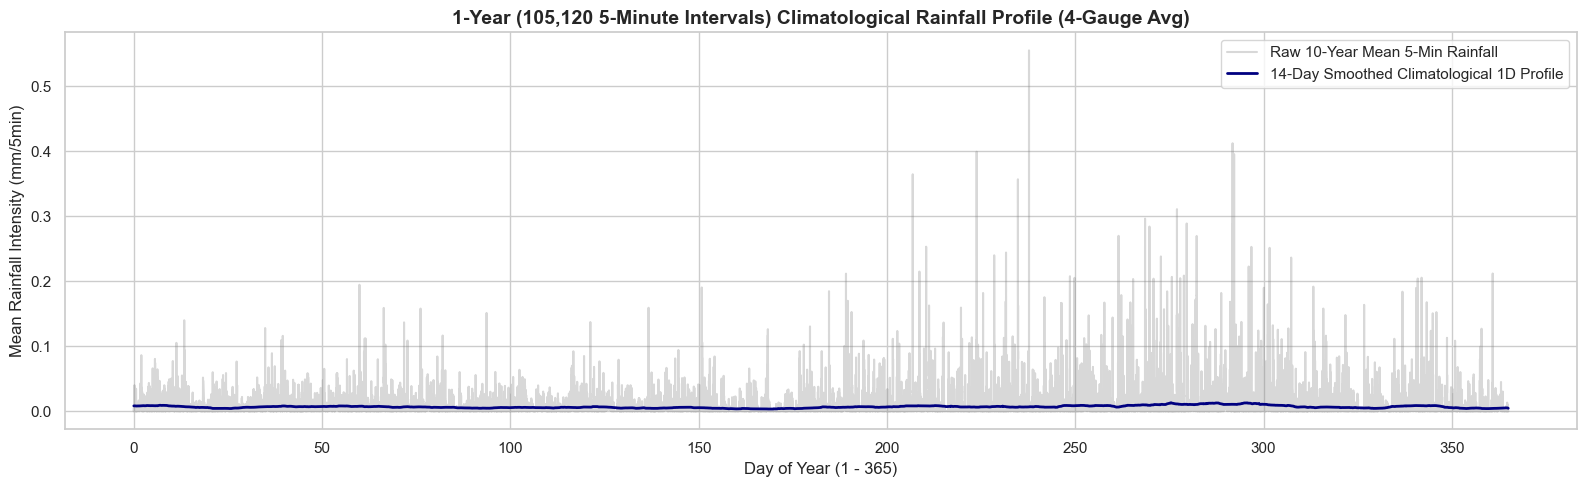

In [6]:
fig, ax = plt.subplots(figsize=(16, 5))
days = clim_105120.index / 288.0
ax.plot(days, clim_105120['rainfall_intensity'], alpha=0.3, color='gray', label='Raw 10-Year Mean 5-Min Rainfall')
ax.plot(days, clim_105120['rainfall_intensity_smooth'], color='navy', linewidth=2, label='14-Day Smoothed Climatological 1D Profile')
ax.set_title('1-Year (105,120 5-Minute Intervals) Climatological Rainfall Profile (4-Gauge Avg)', fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Year (1 - 365)')
ax.set_ylabel('Mean Rainfall Intensity (mm/5min)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Step 3: Fit Gaussian Hidden Markov Model (GaussianHMM) Directly on 105,120 1D Rainfall Profile
We standardize the 105,120 1D smoothed climatological rainfall intensity profile and train a 4-state GaussianHMM directly on the 105,120 interval sequence.

In [8]:
# Standardize features
scaler = StandardScaler()
X_smooth = scaler.fit_transform(clim_105120[['rainfall_intensity_smooth']])

# Train 4-State GaussianHMM on 105,120 intervals directly
n_components = 4
hmm_model = hmm.GaussianHMM(n_components=n_components, covariance_type="diag", n_iter=100, random_state=42)
hmm_model.fit(X_smooth)

# Predict hidden states for all 105,120 intervals
raw_states = hmm_model.predict(X_smooth)
clim_105120['raw_state'] = raw_states

# Reorder states cleanly by mean rainfall intensity
state_means = clim_105120.groupby('raw_state')['rainfall_intensity_smooth'].mean().sort_values()
state_map = {old_st: new_st for new_st, old_st in enumerate(state_means.index)}
clim_105120['hmm_state'] = clim_105120['raw_state'].map(state_map)

state_names = [
    "State 0 (Dry / Low Activity)",
    "State 1 (Light / Moderate Rain)",
    "State 2 (Heavy / Convective Rain)",
    "State 3 (Peak / Intense Storms)"
]

print("HMM Fitting on 105,120 Intervals Complete!")
print("State Mapping (Raw -> Reordered):", state_map)

HMM Fitting on 105,120 Intervals Complete!
State Mapping (Raw -> Reordered): {2: 0, 0: 1, 3: 2, 1: 3}


## Step 4: Observe & Visualize Transition Matrix
We extract the 4x4 state transition matrix from the 105,120 predicted HMM state sequence and render a high-quality heatmap visualization.

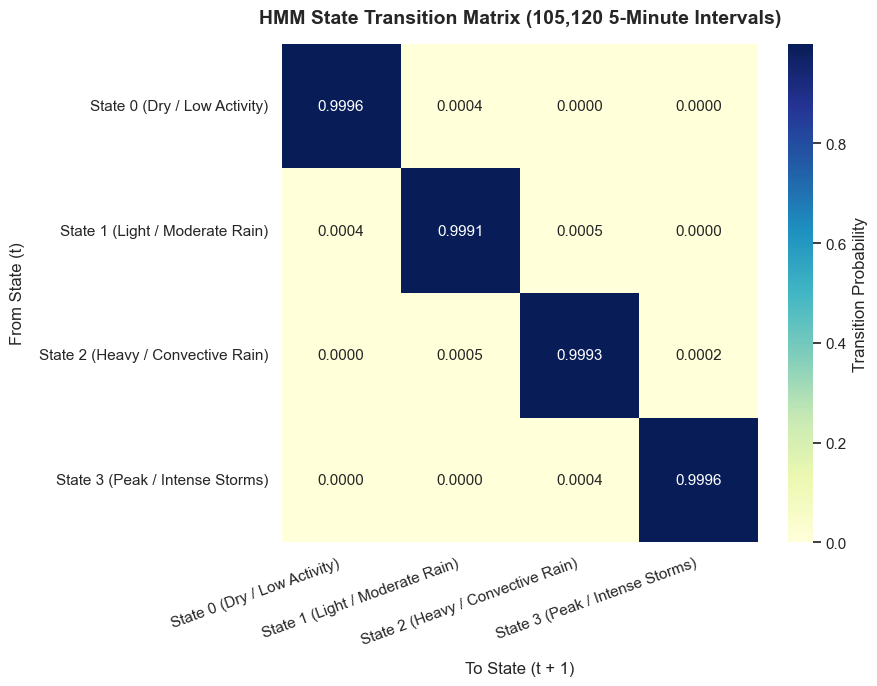

,State 0 (Dry / Low Activity),State 1 (Light / Moderate Rain),State 2 (Heavy / Convective Rain),State 3 (Peak / Intense Storms)
State 0 (Dry / Low Activity),0.999581,0.000419,0.000000,0.000000
State 1 (Light / Moderate Rain),0.000410,0.999117,0.000473,0.000000
State 2 (Heavy / Convective Rain),0.000000,0.000512,0.999328,0.000160
State 3 (Peak / Intense Storms),0.000000,0.000000,0.000369,0.999631


In [10]:
# Compute 4x4 empirical transition matrix across 105,120 intervals
trans_matrix = np.zeros((n_components, n_components))
for t in range(len(clim_105120) - 1):
    i = clim_105120['hmm_state'].iloc[t]
    j = clim_105120['hmm_state'].iloc[t+1]
    trans_matrix[i, j] += 1

# Normalize transition matrix rows to probabilities
trans_matrix_prob = trans_matrix / trans_matrix.sum(axis=1, keepdims=True)

# Plot Transition Matrix Heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(trans_matrix_prob, annot=True, fmt=".4f", cmap="YlGnBu",
            xticklabels=state_names, yticklabels=state_names,
            cbar_kws={'label': 'Transition Probability'})
plt.title("HMM State Transition Matrix (105,120 5-Minute Intervals)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("To State (t + 1)", fontsize=12, labelpad=10)
plt.ylabel("From State (t)", fontsize=12, labelpad=10)
plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Print Transition Probabilities DataFrame
trans_df = pd.DataFrame(trans_matrix_prob, index=state_names, columns=state_names)
trans_df

## Step 5: Visualize 105,120-Interval Climatological Regimes & State Transitions
We plot the 105,120 5-minute annual rainfall profile colored by hidden state transitions across the 365 days of the year.

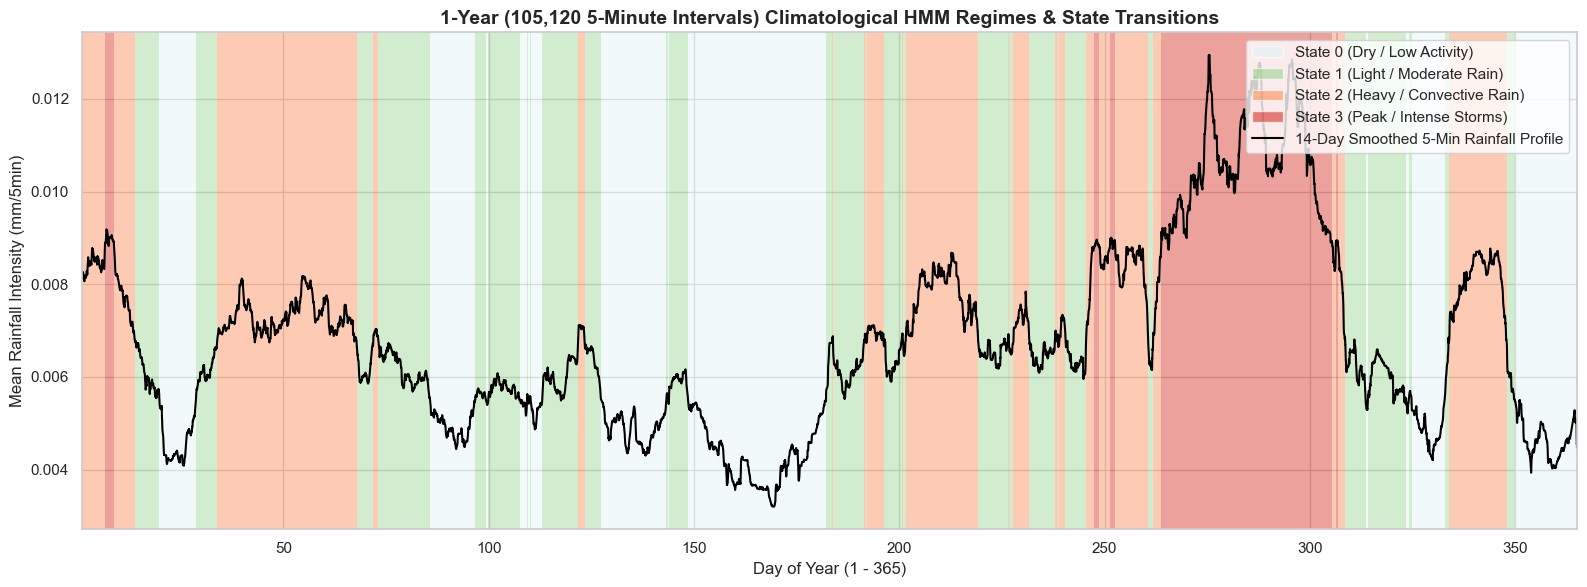

In [12]:
colors = ['#e0f3f8', '#99d594', '#fc8d59', '#d73027']

fig, ax = plt.subplots(figsize=(16, 6))

days = clim_105120.index / 288.0

# Background shading for HMM states across 105,120 intervals
current_state = clim_105120['hmm_state'].iloc[0]
start_idx = 0

for i in range(1, len(clim_105120)):
    if clim_105120['hmm_state'].iloc[i] != current_state or i == len(clim_105120) - 1:
        ax.axvspan(days[start_idx], days[i], color=colors[current_state], alpha=0.45, linewidth=0)
        current_state = clim_105120['hmm_state'].iloc[i]
        start_idx = i

ax.plot(days, clim_105120['rainfall_intensity_smooth'], color='black', linewidth=1.5, label='14-Day Smoothed 5-Min Rainfall')

# Custom legend for HMM states
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i], alpha=0.6, label=state_names[i]) for i in range(4)]
legend_elements.append(plt.Line2D([0], [0], color='black', lw=1.5, label='14-Day Smoothed 5-Min Rainfall Profile'))

ax.set_title('1-Year (105,120 5-Minute Intervals) Climatological HMM Regimes & State Transitions', fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Year (1 - 365)')
ax.set_ylabel('Mean Rainfall Intensity (mm/5min)')
ax.legend(handles=legend_elements, loc='upper right')
ax.set_xlim(1, 365)

plt.tight_layout()
plt.show()

## Step 6: HMM Regime Characterization Summary
We aggregate statistics (mean intensity, interval count, and percentage of year) for each of the 4 discovered HMM states across the 105,120 intervals.

In [14]:
summary_df = clim_105120.groupby('hmm_state')[['rainfall_intensity', 'rainfall_intensity_smooth']].mean()
summary_df['Interval_Count'] = clim_105120.groupby('hmm_state').size()
summary_df['Pct_of_Year'] = (summary_df['Interval_Count'] / len(clim_105120) * 100).round(2)
summary_df.index = state_names
summary_df

,rainfall_intensity,rainfall_intensity_smooth,Interval_Count,Pct_of_Year
State 0 (Dry / Low Activity),0.004637,0.004646,28612,27.22
State 1 (Light / Moderate Rain),0.006057,0.006140,31708,30.16
State 2 (Heavy / Convective Rain),0.007601,0.007694,31242,29.72
State 3 (Peak / Intense Storms),0.010886,0.010479,13558,12.90


## Step 7: Broadcast 105,120-Interval HMM State Sequence to Full 5-Minute Dataset
We map the 105,120 5-minute HMM state sequence (`hmm_state` 0–3) back to each 5-minute record in the 10-year dataset (1,051,200 records) based on `annual_interval_idx`.

In [16]:
# Create mapping from annual_interval_idx (0 to 105,119) to HMM state
interval_state_map = clim_105120['hmm_state'].to_dict()

# Broadcast 105,120 HMM state to full 5-minute dataset
df_5min_full['hmm_state'] = df_5min_full['annual_interval_idx'].map(interval_state_map).astype(int)

df_5min_full['date'] = df_5min_full['datetime'].dt.strftime('%d/%m/%Y')
df_5min_full['time'] = df_5min_full['datetime'].dt.strftime('%H:%M:%S')

print("Broadcasting HMM State Sequence Complete!")
print(f"5-Minute Labeled Dataset Shape: {df_5min_full.shape}")
print("\nDistribution of HMM States in 5-Minute Dataset:")
print(df_5min_full['hmm_state'].value_counts().sort_index())

# Save labeled 5-minute dataset with hmm_state column
output_dir = '../data/rainfall/astlingen/hmm_datasets'
os.makedirs(output_dir, exist_ok=True)

output_csv = os.path.join(output_dir, 'dataset_with_105120_fit_hmm.csv')
df_5min_full[['date', 'time', 'rainfall_intensity', 'day_of_year', 'hmm_state']].to_csv(output_csv, index=False)
print(f"Saved 5-minute dataset with 105,120-fitted HMM states to: {output_csv}")

df_5min_full[['datetime', 'date', 'time', 'rainfall_intensity', 'day_of_year', 'hmm_state']].head(10)

Broadcasting HMM State Sequence Complete!
5-Minute Labeled Dataset Shape: (1051200, 9)

Distribution of HMM States in 5-Minute Dataset:
hmm_state
0    286984
1    317080
2    311556
3    135580
Name: count, dtype: int64
Saved 5-minute dataset with 105,120-fitted HMM states to: ../data/rainfall/astlingen/hmm_datasets/dataset_with_105120_fit_hmm.csv


,datetime,date,time,rainfall_intensity,day_of_year,hmm_state
0,2000-01-01 00:00:00,01/01/2000,00:00:00,0.005,1,2
1,2000-01-01 00:05:00,01/01/2000,00:05:00,0.000,1,2
2,2000-01-01 00:10:00,01/01/2000,00:10:00,0.000,1,2
3,2000-01-01 00:15:00,01/01/2000,00:15:00,0.000,1,2
4,2000-01-01 00:20:00,01/01/2000,00:20:00,0.000,1,2
5,2000-01-01 00:25:00,01/01/2000,00:25:00,0.000,1,2
6,2000-01-01 00:30:00,01/01/2000,00:30:00,0.015,1,2
7,2000-01-01 00:35:00,01/01/2000,00:35:00,0.035,1,2
8,2000-01-01 00:40:00,01/01/2000,00:40:00,0.010,1,2
9,2000-01-01 00:45:00,01/01/2000,00:45:00,0.010,1,2


## Step 8: Visualize 5-Minute Time Series Sample with Broadcasted HMM States
We plot a sample 14-day window of 5-minute rainfall intensity overlaying the broadcasted HMM state background shading.

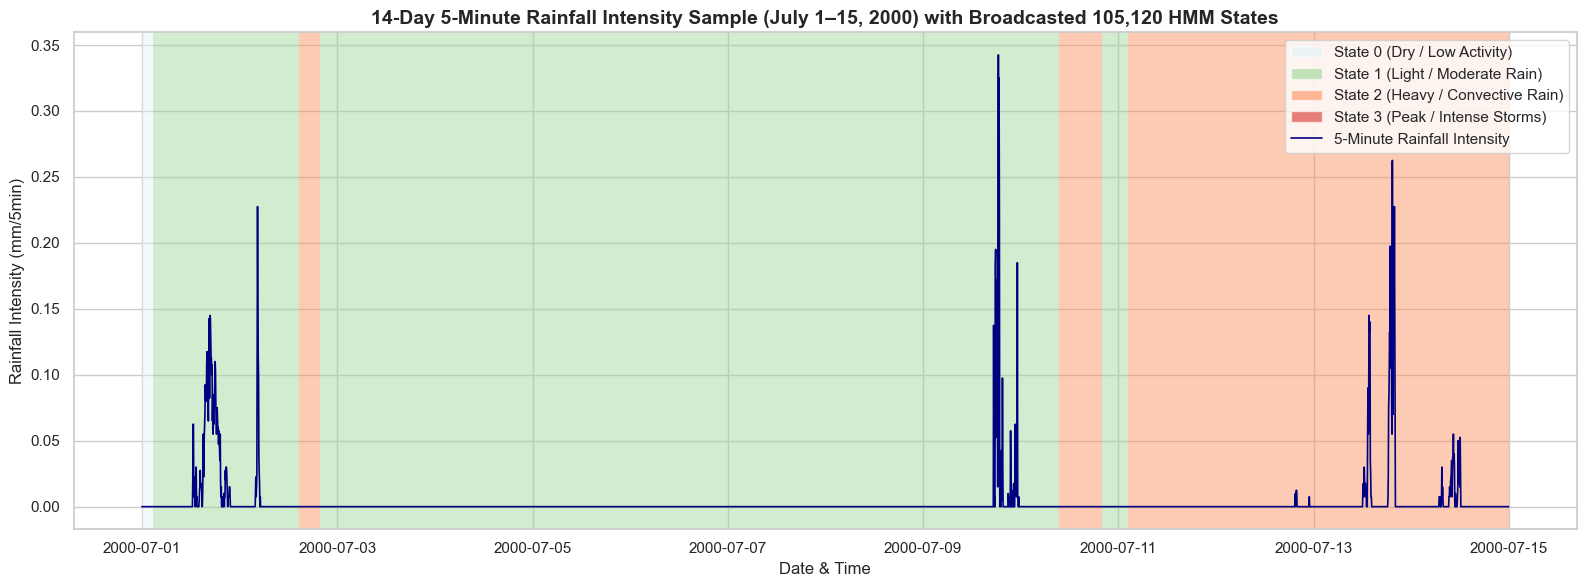

In [18]:
# Sample 14-day window (e.g. July 1 to July 15, 2000)
sample_df = df_5min_full[(df_5min_full['datetime'] >= '2000-07-01') & (df_5min_full['datetime'] < '2000-07-15')].copy()

fig, ax = plt.subplots(figsize=(16, 6))

times = sample_df['datetime']
rain = sample_df['rainfall_intensity']
states = sample_df['hmm_state'].values

# Background shading for broadcasted HMM states
current_st = states[0]
start_t = times.iloc[0]

for i in range(1, len(sample_df)):
    if states[i] != current_st or i == len(sample_df) - 1:
        ax.axvspan(start_t, times.iloc[i], color=colors[current_st], alpha=0.45, linewidth=0)
        current_st = states[i]
        start_t = times.iloc[i]

ax.plot(times, rain, color='navy', linewidth=1.2, label='5-Minute Rainfall Intensity')

legend_elements = [Patch(facecolor=colors[i], alpha=0.6, label=state_names[i]) for i in range(4)]
legend_elements.append(plt.Line2D([0], [0], color='navy', lw=1.2, label='5-Minute Rainfall Intensity'))

ax.set_title('14-Day 5-Minute Rainfall Intensity Sample (July 1–15, 2000) with Broadcasted 105,120 HMM States', fontsize=14, fontweight='bold')
ax.set_xlabel('Date & Time')
ax.set_ylabel('Rainfall Intensity (mm/5min)')
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()